In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import torch
import numpy as np
import pandas as pd

from flonacomldft.utils.io_utils import (
    load_pickle_file,
    get_project_path
)

from flonacomldft.internal_coordinates import (
    get_collective_variables_from_xs
)


from flonacomldft.utils.diagnostics import R_hat

from ase.units import kB

In [3]:
methods = ['adaptive', 'mixture_model']

In [4]:
simulation_types = dict(zip( methods, [
                    ['ab-flowMC', 'ab-flowMC w.o. MLP'],
                    ['ab-flowMM', 'ab-flowMM w.o. MLP']
                ])
            )

In [5]:
simulation_types

{'adaptive': ['ab-flowMC', 'ab-flowMC w.o. MLP'],
 'mixture_model': ['ab-flowMM', 'ab-flowMM w.o. MLP']}

In [6]:
simulation_idxs = { methods[0]: { simulation_types[methods[0]][0]: {
                        #0: 31959918,
                        #1: 319599111
                        #0: 31959917,
                        #1: 319599110,
                        #0: 31959916,
                        #1: 31959919,
                        #0: 32504326,
                        #1: 32510291,
                        0: 32606140,
                        1: 32606143
                    },

                    simulation_types[methods[0]][1]: {
                        0: 31961552,
                        1: 31961553
                    }
                },

                methods[1]: { 
                    simulation_types[methods[1]][0]:
                        #32948391,
                        32901861, 
                        #32760171, 
                        #32094541,
                    simulation_types[methods[1]][1]:
                        32094594
                        
                }
            }

In [7]:
simulation_idxs

{'adaptive': {'ab-flowMC': {0: 32606140, 1: 32606143},
  'ab-flowMC w.o. MLP': {0: 31961552, 1: 31961553}},
 'mixture_model': {'ab-flowMM': 32901861, 'ab-flowMM w.o. MLP': 32094594}}

In [8]:
simulations_folders = {
    
    methods[0]: {
    simulation_types[methods[0]][0]: get_project_path() + "/2-adaptive-mlp",
    simulation_types[methods[0]][1]: get_project_path() + "/1-adaptive"
    },

    methods[1]: {
    simulation_types[methods[1]][0]: get_project_path() + "/5-multimodal-mlp",
    simulation_types[methods[1]][1]: get_project_path() + "/4-multimodal"
    }
}

save_path = get_project_path() + "/figures/preprint_v2/data"

In [9]:
simulations_folders

{'adaptive': {'ab-flowMC': '/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp',
  'ab-flowMC w.o. MLP': '/mnt/home/amolina/ceph/adaptive-flow-mc/1-adaptive'},
 'mixture_model': {'ab-flowMM': '/mnt/home/amolina/ceph/adaptive-flow-mc/5-multimodal-mlp',
  'ab-flowMM w.o. MLP': '/mnt/home/amolina/ceph/adaptive-flow-mc/4-multimodal'}}

In [10]:
get_simulation_filename_adaptive = lambda isomer_label, idx: "results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl".format(
    isomer_label, idx, isomer_label, idx)
get_cvs_filename_adaptive = lambda isomer_label, idx: "results_adaptive_is{:d}_{:d}/cvs_is{:d}_{:d}.pkl".format(
    isomer_label, idx, isomer_label, idx)

In [11]:
get_simulation_filename_mm = lambda idx, nsteps: "results_multimodal_sampling_mixture_{:d}/checkpoint_NA_{:d}.pkl".format(
    idx, nsteps)
get_cvs_filename_mm = lambda idx, nsteps: "cvs_temporal/cvs_slices_{:d}_{:d}.pkl".format(
    idx, nsteps)

In [12]:
simulations_folders[methods[0]]

{'ab-flowMC': '/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp',
 'ab-flowMC w.o. MLP': '/mnt/home/amolina/ceph/adaptive-flow-mc/1-adaptive'}

# 1. Ab-flowMC simulations

In [13]:
method = methods[0]

adaptives = {}
cvss = {}

print("Loading data...")
for simulation in simulation_types[method]:
    adaptives[simulation] = {}
    cvss[simulation] = {}
    for key, idx in simulation_idxs[method][simulation].items():
        adaptives[simulation][key] = load_pickle_file(get_simulation_filename_adaptive(key, idx), 
        simulations_folders[method][simulation])
        cvss[simulation][key] = load_pickle_file(get_cvs_filename_adaptive(key, idx),
        simulations_folders[method][simulation])
        print("Loaded adaptive sampling {:s} and cvs for isomer {:d} and idx {:d}".format(
            simulation, key, idx))

Loading data...


Loaded adaptive sampling ab-flowMC and cvs for isomer 0 and idx 32606140
Loaded adaptive sampling ab-flowMC and cvs for isomer 1 and idx 32606143
Loaded adaptive sampling ab-flowMC w.o. MLP and cvs for isomer 0 and idx 31961552
Loaded adaptive sampling ab-flowMC w.o. MLP and cvs for isomer 1 and idx 31961553


In [14]:
adaptive = adaptives[simulation_types[method][0]][0]

## 1.a Acceptance rate

In [15]:
accs_df = []

for simulation in simulation_types[method]:
    
    for key, idx in simulation_idxs[method][simulation].items():

        df = pd.DataFrame(columns=['Method', 'Isomer', 'Step', 'Acceptance Rate'])
        accs = torch.cat(adaptives[simulation][key]['accs']).float().mean(dim=1).numpy()

        df['Acceptance Rate'] = accs
        df['Isomer'] = key
        df['Step'] = np.arange(0, len(accs))
        df['Method'] = simulation

        accs_df.append(df)

accs_df = pd.concat(accs_df)
accs_df.to_csv(save_path + "/acceptance_rates.csv", index=False)
print("Acceptance rates saved to {:s}".format(save_path + "/acceptance_rates.csv"))

Acceptance rates saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/acceptance_rates.csv


## 1.b Collective variables and potential energy

In [16]:
cvs_us_df = []

for simulation in simulation_types[method]:
    for isomer_label in [0, 1]:

        us = torch.cat(adaptives[simulation][isomer_label]['us']).reshape(1000, 50, 1)
        cvs = cvss[simulation][isomer_label]

        cvs_us = torch.cat([us, cvs], dim=2).numpy().reshape(50000, 3)

        df = pd.DataFrame(cvs_us, columns=['U', 'C', 'R'])
        df['Isomer'] = isomer_label
        df['Method'] = simulation

        cvs_us_df.append(df)

cvs_us_df = pd.concat(cvs_us_df)
cvs_us_df.to_csv(save_path + "/cvs_potential_energy.csv", index=False)
print("CVs and potential energy saved to {:s}".format(save_path + "/cvs_potential_energy.csv"))
cvs_us_df

CVs and potential energy saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/cvs_potential_energy.csv


,U,C,R,Isomer,Method
0,-6.750925,9.576655,2.486875,0,ab-flowMC
1,-6.786580,9.442955,2.478133,0,ab-flowMC
2,-6.701509,10.996526,2.398707,0,ab-flowMC
3,-6.640422,10.196114,2.435974,0,ab-flowMC
4,-6.755364,9.775428,2.466949,0,ab-flowMC
...,...,...,...,...,...
49995,-6.704685,10.828248,2.220704,1,ab-flowMC w.o. MLP
49996,-6.746437,10.425041,2.232781,1,ab-flowMC w.o. MLP
49997,-6.714196,11.065727,2.218863,1,ab-flowMC w.o. MLP
49998,-6.743561,11.145951,2.213711,1,ab-flowMC w.o. MLP


## 1.c Rhat

In [17]:
rhat_df = []

for simulation in simulation_types[method]:
    for isomer_label in [0, 1]:

        us = torch.cat(adaptives[simulation][isomer_label]['us']).reshape(1000, 50, 1)
        cvs = cvss[simulation][isomer_label]
        
        time_slices = adaptives[simulation][isomer_label]['time_mcmc']
        time_flatten = [t for time_slice in time_slices for t in time_slice]
        time_min = min(time_flatten)
        time_mcmc = np.array([t - time_min for t in time_flatten])/3600

        rhat_info = torch.cat((cvs, us), dim=2).detach().numpy()[:].transpose(1, 0, 2)

        rhat = R_hat(rhat_info, labels=['C', 'R', 'U'])

        df = pd.DataFrame(rhat[0], columns=['C', 'R', 'U'])
        df['Time (h)'] = time_mcmc[rhat[1]]
        df['MCMC step'] = rhat[1]
        df['Method'] = simulation
        df['Isomer'] = isomer_label

        rhat_df.append(df)

rhat_df = pd.concat(rhat_df)
rhat_df.to_csv(save_path + "/rhat.csv", index=False)        
rhat_df

,C,R,U,Time (h),MCMC step,Method,Isomer
0,1.114298,1.135346,1.110416,6.130083,90,ab-flowMC,0
1,1.072752,1.064500,1.054616,9.483880,180,ab-flowMC,0
2,1.041248,1.039257,1.039189,11.651488,270,ab-flowMC,0
3,1.034388,1.028895,1.028274,13.651694,360,ab-flowMC,0
4,1.024605,1.022147,1.022185,15.657979,450,ab-flowMC,0
5,1.018917,1.018480,1.018093,17.700629,540,ab-flowMC,0
6,1.015433,1.015258,1.013192,19.740342,630,ab-flowMC,0
7,1.012795,1.013567,1.011050,21.806306,720,ab-flowMC,0
8,1.009842,1.011784,1.010485,23.705137,810,ab-flowMC,0
9,1.008763,1.009829,1.008933,25.739646,900,ab-flowMC,0


## 1.d MLP datasets

In [18]:
mlp_datasets_df = []

simulation = simulation_types[method][0]

for isomer_label in [0, 1]:
    datasets = adaptives[simulation][isomer_label]['mlps_datasets']
    models = adaptives[simulation][isomer_label]['dict_mlps'][-1][0]['model']
    for key in ['train', 'test']:
        df = pd.DataFrame(columns=['Predictions', 'True values'])
    
        data = datasets[key][0].detach().numpy()
        predict = models(torch.tensor(data[:, :12]).float()).detach().numpy()

        df['True values'] = data[:, 12]
        df['Predictions'] = predict
        df['Isomer'] = isomer_label
        df['Dataset'] = key.capitalize()
        df['Method'] = simulation

        mlp_datasets_df.append(df)

mlp_datasets_df = pd.concat(mlp_datasets_df)
mlp_datasets_df.to_csv(save_path + "/mlp_datasets.csv", index=False)
print("MLP datasets saved to {:s}".format(save_path + "/mlp_datasets.csv"))


MLP datasets saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/mlp_datasets.csv


## 1.d Optical spectrum

In [19]:
path_opt_spc_dft = get_project_path() + '/8-optical-spectra'

### 1.d.ii Minima 0K

In [20]:
data0K_is0 = np.loadtxt(path_opt_spc_dft +'/minima_is0/spectrum_with_05.50eV.dat', skiprows=1)
data0K_is1 = np.loadtxt(path_opt_spc_dft +'/minima_is1/spectrum_with_05.50eV.dat', skiprows=1)

### 1.d.ii MD 350K

In [21]:
data350_md_all = {i: pd.read_csv( save_path + '/is{:d}_opt_spc_MD_350K.csv'.format(i)) for i in range(2)}

data350_md = {i: {} for i in range(2)}

for i in range(2):
    data350_md[i]['means'] = data350_md_all[i][data350_md_all[i].columns[1:]].mean(axis=1)
    data350_md[i]['stds'] = data350_md_all[i][data350_md_all[i].columns[1:]].std(axis=1)/np.sqrt(data350_md_all[i].shape[1])

### 1.d.i Ab-flowMC 350K

In [22]:
path_opt_spc_mlp = get_project_path() + '/9-optical-spectra-mlp'

data350K_is0_mlp = [np.loadtxt(path_opt_spc_mlp +'/is0_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format(
                                    simulation_idxs[methods[0]]['ab-flowMC'][0], i),
                               skiprows=1) for i in range(50) ]
data350K_is1_mlp = [np.loadtxt(path_opt_spc_mlp +'/is1_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format(
                                    simulation_idxs[methods[0]]['ab-flowMC'][1], i),
                                 skiprows=1) for i in range(50) ]

Ydata350K_is0_mlp = np.array([data350K_is0_mlp[i][:,1] for i in range(len(data350K_is0_mlp))])
Ydata350K_is1_mlp = np.array([data350K_is1_mlp[i][:,1] for i in range(len(data350K_is1_mlp))])

mean_is0_mlp = np.mean(Ydata350K_is0_mlp, axis=0)
std_is0_mlp = np.std(Ydata350K_is0_mlp, axis=0)/np.sqrt(Ydata350K_is0_mlp.shape[0])

mean_is1_mlp = np.mean(Ydata350K_is1_mlp, axis=0)
std_is1_mlp = np.std(Ydata350K_is1_mlp, axis=0)/np.sqrt(Ydata350K_is1_mlp.shape[0])

### 1.d.ii Ab-flowMC w.o. MLP 350K

In [23]:
n=50

data350K_is0_dft = [np.loadtxt(path_opt_spc_dft +'/is0_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format( 
                        simulation_idxs[methods[0]]['ab-flowMC w.o. MLP'][0], i), 
                           skiprows=1) for i in range(n)]

data350K_is1_dft = [np.loadtxt(path_opt_spc_dft +'/is1_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format( 
                        simulation_idxs[methods[0]]['ab-flowMC w.o. MLP'][1], i),
                            skiprows=1) for i in range(n)]

Ydata350K_is0_dft = np.array([data350K_is0_dft[i][:,1] for i in range(n)])
Ydata350K_is1_dft = np.array([data350K_is1_dft[i][:,1] for i in range(n)])

mean_is0_dft = np.mean(Ydata350K_is0_dft, axis=0)
std_is0_dft = np.std(Ydata350K_is0_dft, axis=0)/np.sqrt(Ydata350K_is0_dft.shape[0])


mean_is1_dft = np.mean(Ydata350K_is1_dft, axis=0)
std_is1_dft = np.std(Ydata350K_is1_dft, axis=0)/np.sqrt(Ydata350K_is1_dft.shape[0])


In [24]:
data_optical_spectra = {'T0K_is0_dft': data0K_is0[:,1],
                        'T0K_is1_dft': data0K_is1[:,1],
                        'mean_350K_is0_dft': mean_is0_dft, 
                        'mean_350K_is1_dft': mean_is1_dft,
                        'mean_350K_is0_mlp': mean_is0_mlp, 
                        'mean_350K_is1_mlp': mean_is1_mlp,
                        'std_350K_is0_dft': std_is0_dft,
                        'std_350K_is1_dft': std_is1_dft,
                        'std_350K_is0_mlp': std_is0_mlp,
                        'std_350K_is1_mlp': std_is1_mlp,
                        'mean_350K_is0_md': data350_md[0]['means'],
                        'mean_350K_is1_md': data350_md[1]['means'],
                        'std_350K_is0_md': data350_md[0]['stds'],
                        'std_350K_is1_md': data350_md[1]['stds'],
                        'energy': data0K_is0[:,0]}

df = pd.DataFrame(data_optical_spectra)
df.to_csv(save_path + '/optical_spectra.csv', index=False)

# 2. Ab-flowMC pretrained models

In [25]:
pretrained_simulation_idxs = { 
                        0: 30019620,
                        1: 30019624
            }

In [26]:
methods, simulations_folders

(['adaptive', 'mixture_model'],
 {'adaptive': {'ab-flowMC': '/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp',
   'ab-flowMC w.o. MLP': '/mnt/home/amolina/ceph/adaptive-flow-mc/1-adaptive'},
  'mixture_model': {'ab-flowMM': '/mnt/home/amolina/ceph/adaptive-flow-mc/5-multimodal-mlp',
   'ab-flowMM w.o. MLP': '/mnt/home/amolina/ceph/adaptive-flow-mc/4-multimodal'}})

In [27]:
pretrained_adaptives = {}
pretrained_cvss = {}

print("Loading data...")

for key, idx in pretrained_simulation_idxs.items():
    print(key, idx)
    pretrained_adaptives[key] = load_pickle_file(get_simulation_filename_adaptive(key, idx), 
    simulations_folders['adaptive']['ab-flowMC'])
    pretrained_cvss[key] = load_pickle_file(get_cvs_filename_adaptive(key, idx),
    simulations_folders['adaptive']['ab-flowMC'])
    print("Loaded adaptive sampling {:s} and cvs for isomer {:d} and idx {:d}".format(
        'pretrained ab-flowMC', key, idx))

Loading data...
0 30019620


Loaded adaptive sampling pretrained ab-flowMC and cvs for isomer 0 and idx 30019620
1 30019624
Loaded adaptive sampling pretrained ab-flowMC and cvs for isomer 1 and idx 30019624


## Acceptance rate

In [28]:
pretrained_accs_df = []

for key, idx in pretrained_simulation_idxs.items():

    df = pd.DataFrame(columns=['Method', 'Isomer', 'Step', 'Acceptance Rate'])
    accs = torch.cat(pretrained_adaptives[key]['accs']).float().mean(dim=1).numpy()

    df['Acceptance Rate'] = accs
    df['Isomer'] = key
    df['Step'] = np.arange(0, len(accs))
    df['Method'] = 'Pretrained ab-flowMC'

    pretrained_accs_df.append(df)

pretrained_accs_df = pd.concat(pretrained_accs_df)
pretrained_accs_df
pretrained_accs_df.to_csv(save_path + "/pretrained_acceptance_rates.csv", index=False)
print("Acceptance rates saved to {:s}".format(save_path + "/acceptance_rates.csv"))

Acceptance rates saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/acceptance_rates.csv


## Rhat

In [29]:
pretrained_rhat_df = []
md_time = {0: 45870.99/2, 1: 45600.62/2}

for key, idx in pretrained_simulation_idxs.items():

    us = torch.cat(pretrained_adaptives[key]['us']).reshape(600, 50, 1)
    cvs = pretrained_cvss[key]
    
    time_slices = pretrained_adaptives[key]['time_mcmc']
    time_flatten = [t for time_slice in time_slices for t in time_slice]
    time_min = min(time_flatten)
    time_mcmc = np.array([t - time_min for t in time_flatten])/3600

    rhat_info = torch.cat((cvs, us), dim=2).detach().numpy()[:].transpose(1, 0, 2)

    rhat = R_hat(rhat_info, labels=['C', 'R', 'U'])

    df = pd.DataFrame(rhat[0], columns=['C', 'R', 'U'])
    df['Time (h)'] = time_mcmc[rhat[1]] + md_time[key]/3600 + 5*10000/3600 + 19/60
    df['MCMC step'] = rhat[1]
    df['Method'] = 'Pretrained ab-flowMC'
    df['Isomer'] = key

    pretrained_rhat_df.append(df)

pretrained_rhat_df = pd.concat(pretrained_rhat_df)
pretrained_rhat_df.to_csv(save_path + "/pretrained_rhat.csv", index=False)        
pretrained_rhat_df

,C,R,U,Time (h),MCMC step,Method,Isomer
0,1.166420,1.193210,1.196138,21.612536,50,Pretrained ab-flowMC,0
1,1.105677,1.072118,1.084185,22.693926,100,Pretrained ab-flowMC,0
2,1.062846,1.051407,1.055151,23.769784,150,Pretrained ab-flowMC,0
3,1.049411,1.041093,1.038211,24.893809,200,Pretrained ab-flowMC,0
4,1.038577,1.040149,1.030867,25.994427,250,Pretrained ab-flowMC,0
5,1.027576,1.038054,1.024118,27.158230,300,Pretrained ab-flowMC,0
6,1.023279,1.035647,1.020727,28.290693,350,Pretrained ab-flowMC,0
7,1.021595,1.032937,1.024681,29.480599,400,Pretrained ab-flowMC,0
8,1.022615,1.035250,1.024158,30.643917,450,Pretrained ab-flowMC,0
9,1.018832,1.031564,1.020237,31.864745,500,Pretrained ab-flowMC,0


# 3. Ab-flowMM

In [30]:
method = methods[1]

mixture_models = {}
cvs_mixture_models = {}

print("Loading data...")
nsteps = [5500, 3000]
i=0
for key, idx  in simulation_idxs[method].items():
    print(key, idx)
    mixture_models[key] = load_pickle_file(get_simulation_filename_mm(idx, nsteps[i]), 
    simulations_folders[method][key])
    cvs_mixture_models[key] = load_pickle_file(get_cvs_filename_mm(idx, nsteps[i]),
    get_project_path())
    print("Loaded mixture model sampling {:s} and cvs and idx {:d}".format(
        key, idx))
    i=i+1

Loading data...
ab-flowMM 32901861


Loaded mixture model sampling ab-flowMM and cvs and idx 32901861
ab-flowMM w.o. MLP 32094594
Loaded mixture model sampling ab-flowMM w.o. MLP and cvs and idx 32094594


## 2a. Acceptace rate

In [31]:
mixture_models.keys()

dict_keys(['ab-flowMM', 'ab-flowMM w.o. MLP'])

In [32]:
accs_df_mm = []

    
for key in mixture_models.keys():

    df = pd.DataFrame(columns=['Method', 'Isomer', 'Step', 'Acceptance Rate'])
    accs = mixture_models[key]['accs'].float().mean(dim=1).numpy()

    df['Acceptance Rate'] = accs
    df['Isomer'] = key
    df['Step'] = np.arange(0, len(accs))
    df['Method'] = key

    accs_df_mm.append(df)

accs_df_mm = pd.concat(accs_df_mm)
accs_df_mm.to_csv(save_path + "/acceptance_rates_mm.csv", index=False)
print("Acceptance rates saved to {:s}".format(save_path + "/acceptance_rates_mm.csv"))

Acceptance rates saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/acceptance_rates_mm.csv


In [33]:
accs_df_mm

,Method,Isomer,Step,Acceptance Rate
0,ab-flowMM,ab-flowMM,0,0.40
1,ab-flowMM,ab-flowMM,1,0.40
2,ab-flowMM,ab-flowMM,2,0.20
3,ab-flowMM,ab-flowMM,3,0.25
4,ab-flowMM,ab-flowMM,4,0.45
...,...,...,...,...
2996,ab-flowMM w.o. MLP,ab-flowMM w.o. MLP,2996,0.25
2997,ab-flowMM w.o. MLP,ab-flowMM w.o. MLP,2997,0.30
2998,ab-flowMM w.o. MLP,ab-flowMM w.o. MLP,2998,0.50
2999,ab-flowMM w.o. MLP,ab-flowMM w.o. MLP,2999,0.45


## 2.b Collective variables and potential energy

In [34]:
cvs_us_df_mm = []
i=0
for key in mixture_models.keys():

    us = mixture_models[key]['us'].reshape(nsteps[i]+1, 20, 1)
    isomers = mixture_models[key]['isomers'].reshape(nsteps[i]+1, 20, 1)
    cvs = cvs_mixture_models[key]
    cvs_us = torch.cat([us, cvs, isomers], dim=2).numpy().reshape((nsteps[i]+1)*20, 4)
    df = pd.DataFrame(cvs_us, columns=['U', 'C', 'R', 'Isomer'])
    df['Method'] = key
    cvs_us_df_mm.append(df)
    i=i+1

cvs_us_df_mm = pd.concat(cvs_us_df_mm)
cvs_us_df_mm.to_csv(save_path + "/cvs_potential_energy_mm.csv", index=False)
print("CVs and potential energy saved to {:s}".format(save_path + "/cvs_potential_energy.csv"))
cvs_us_df_mm

CVs and potential energy saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/cvs_potential_energy.csv


,U,C,R,Isomer,Method
0,-6.760328,9.791974,2.467646,0.0,ab-flowMM
1,-6.734219,9.800680,2.460909,0.0,ab-flowMM
2,-6.655677,10.075570,2.267882,1.0,ab-flowMM
3,-6.629371,9.502993,2.451487,0.0,ab-flowMM
4,-6.567653,10.283319,2.221862,1.0,ab-flowMM
...,...,...,...,...,...
60015,-6.587486,9.258082,2.489870,0.0,ab-flowMM w.o. MLP
60016,-6.651504,9.766457,2.434023,0.0,ab-flowMM w.o. MLP
60017,-6.752233,9.839469,2.444603,0.0,ab-flowMM w.o. MLP
60018,-6.800272,10.247417,2.428397,0.0,ab-flowMM w.o. MLP


## 2.c Density samples

In [35]:
density_samples_dfs = []

n_samples = 200

for key in mixture_models.keys():
    
    density_xs = mixture_models[key]['xs_proposals'][-n_samples:]
    density_isomers = mixture_models[key]['isomers_proposals'][-n_samples:]

    density_xs = density_xs.reshape(density_xs.shape[0]*density_xs.shape[1], 1, density_xs.shape[2])
    density_isomers = density_isomers.reshape(-1, 1)

    density_cvs = get_collective_variables_from_xs(density_xs,
                                            density_isomers).squeeze()

    density_samples = torch.cat((density_cvs, density_isomers), dim=1).detach().numpy()

    df = pd.DataFrame(columns = ['Method', 'C', 'R', 'Isomer'])

    df[['C', 'R', 'Isomer']] = density_samples
    df['Method'] = key

    #print(df)

    density_samples_dfs.append(df)

density_samples_dfs = pd.concat(density_samples_dfs)
density_samples_dfs.to_csv(save_path + "/density_samples_mm.csv", index=False)
print("Density samples saved to {:s}".format(save_path + "/density_samples_mm.csv"))
density_samples_dfs

Density samples saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/density_samples_mm.csv


,Method,C,R,Isomer
0,ab-flowMM,9.685730,2.487888,0.0
1,ab-flowMM,10.125398,2.464506,0.0
2,ab-flowMM,9.265795,2.509405,0.0
3,ab-flowMM,10.895290,2.225892,1.0
4,ab-flowMM,10.566280,2.405446,0.0
...,...,...,...,...
3995,ab-flowMM w.o. MLP,10.535815,2.239338,1.0
3996,ab-flowMM w.o. MLP,10.653555,2.430594,0.0
3997,ab-flowMM w.o. MLP,11.559838,2.168795,1.0
3998,ab-flowMM w.o. MLP,11.150782,2.212697,1.0


## 2.d Rhat

In [36]:
rhat_df_mm = []
i=0
for key in mixture_models.keys():

    us = mixture_models[key]['us'].reshape(nsteps[i]+1, 20, 1)
    cvs = cvs_mixture_models[key]
    
    time_mm = mixture_models[key]['time_mcmc']
    time_min = min(time_mm)
    time_mcmc = np.array([t - time_min for t in time_mm])/3600

    rhat_info = torch.cat((cvs, us), dim=2).detach().numpy().transpose(1, 0, 2)

    rhat = R_hat(rhat_info, labels=['C', 'R', 'U'])

    df = pd.DataFrame(rhat[0], columns=['C', 'R', 'U'])
    df['Time (h)'] = time_mcmc[rhat[1]]
    df['MCMC step'] = rhat[1]
    df['Method'] = key

    rhat_df_mm.append(df)
    i=i+1
    
rhat_df_mm = pd.concat(rhat_df_mm)
rhat_df_mm.to_csv(save_path + "/rhat_mm.csv", index=False)        
rhat_df_mm

,C,R,U,Time (h),MCMC step,Method
0,1.044515,1.063757,1.051680,3.292408,540,ab-flowMM
1,1.038594,1.035785,1.068802,6.709903,1080,ab-flowMM
2,1.032629,1.041297,1.039622,10.664510,1620,ab-flowMM
3,1.076813,1.084334,1.065392,14.824391,2160,ab-flowMM
4,1.088429,1.096616,1.051165,19.568906,2700,ab-flowMM
5,1.062691,1.079826,1.034943,25.750572,3240,ab-flowMM
6,1.043071,1.063466,1.033372,32.370817,3780,ab-flowMM
7,1.034765,1.061615,1.028731,41.103585,4320,ab-flowMM
8,1.028963,1.054854,1.020941,49.960928,4860,ab-flowMM
9,1.026439,1.044604,1.018706,61.736554,5401,ab-flowMM


## 2.e Isomers

In [37]:
isomers_jumps = []
i=0
for key in mixture_models.keys():
    
    isomers = mixture_models[key]['isomers'].int()#.reshape(3001, 20, 1)

    df = pd.DataFrame(isomers, columns=['chain {:d}'.format(i) for i in np.arange(20)])
    df['Step'] = np.arange(0, nsteps[i]+1)
    df['Method'] = key
    
    isomers_jumps.append(df)
    i=i+1
    
isomers_jumps = pd.concat(isomers_jumps)
isomers_jumps.to_csv(save_path + "/isomers_jumps_mm.csv", index=False)
print("Isomers jumps saved to {:s}".format(save_path + "/isomers_jumps_mm.csv"))

Isomers jumps saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/isomers_jumps_mm.csv


## 2.f Populations

In [60]:
mm_idx = {'ab-flowMM': {
            #5: 32948390,
            5: 32901860,
            #5: 32760170,
            #5: 32094540,
            
            #15: 32948391,
            15: 32901861,
            #15: 32760171,
            #15: 32094541,
            
            #30: 32948392,
            30: 32901862,
            #30: 32760172,
            #30: 32094542 
            },
        
        'ab-flowMM w.o. MLP': {5: 32094593,
            15: 32094594,
            30: 32094595    
            }
        }

In [61]:
mixture_models_populations = {}

for method in mm_idx.keys():
    
    mixture_models_populations[method] = {}

    for key, idx in mm_idx[method].items():
        mixture_models_populations[method][key] = load_pickle_file(get_simulation_filename_mm(idx, 3000), 
        simulations_folders['mixture_model'][method])['isomers']

In [62]:
#isomers = mixture_models_populations['ab-flowMM'][5][250:].detach().numpy()
#means = isomers.T.reshape(10, isomers.shape[0]*2).mean(axis=1)
#stds = isomers.T.reshape(10, isomers.shape[0]*2).std(axis=1)

In [63]:
populations_mm_df = [] 

for key in mixture_models_populations.keys():

    for i in mixture_models_populations[key].keys():
        
        populations_mm = pd.DataFrame()

        isomers_selection = mixture_models_populations[key][i][-2750:].detach().numpy()
        means = isomers_selection.T.reshape(10, isomers_selection.shape[0]*2).mean(axis=1)
        stds = isomers_selection.T.reshape(10, isomers_selection.shape[0]*2).std(axis=1)
        
        populations_mm['means'] = means
        populations_mm['stds'] = stds
        populations_mm['slice'] = i
        populations_mm['Method'] = key
        
        if key=='ab-flowMM w.o. MLP':
            
            populations_mm['# DFT evaluations'] = int( (1000 + 2*50*20*i + 20*3000) / 1000)

        if key=='ab-flowMM':
            evals = 2000 + int(20*7000*0.2)
            if i==5:
                evals = evals + 2*50*20*i
            elif i==15:
                evals = evals + 2*50*20*5 + 2*int(50*20*5*0.5) + 2*int(50*20*5*0.3)
            elif i==30:
                evals = evals + 2*50*20*5 + 2*int(50*20*5*0.5) + 2*int(50*20*20*0.3) 

            populations_mm['# DFT evaluations'] = int(evals/1000)
        
        populations_mm_df.append(populations_mm)

populations_mm_df = pd.concat(populations_mm_df)
populations_mm_df.to_csv(save_path + "/populations_mm.csv", index=False)
print("Populations saved to {:s}".format(save_path + "/populations_mm.csv"))

Populations saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/populations_mm.csv


In [64]:
populations_mm_df

,means,stds,slice,Method,# DFT evaluations
0,0.005273,0.072422,5,ab-flowMM,40
1,0.007091,0.083908,5,ab-flowMM,40
2,0.003091,0.055510,5,ab-flowMM,40
3,0.006182,0.078381,5,ab-flowMM,40
4,0.004000,0.063119,5,ab-flowMM,40
5,0.003455,0.058674,5,ab-flowMM,40
6,0.031091,0.173563,5,ab-flowMM,40
7,0.005273,0.072422,5,ab-flowMM,40
8,0.005091,0.071169,5,ab-flowMM,40
9,0.005455,0.073653,5,ab-flowMM,40


# Supplementary figures

## NLL vs Potential energy

In [43]:
nlls_df = []
beta = 1/(kB*350)
for method in adaptives.keys():

    for isomer in adaptives[method].keys():

        df = pd.DataFrame(columns=['Method', 'Isomer', 'nlls', 'us', 'Step'])

        nlls = torch.stack(adaptives[method][isomer]['nlls_proposals']).flatten().detach().numpy()
        us = torch.stack(adaptives[method][isomer]['us_proposals']).flatten().detach().numpy()
        df['nlls'] = nlls/beta
        df['us'] = us
        df['Method'] = method
        df['Isomer'] = isomer
        df['Step'] = np.arange(len(nlls))

        nlls_df.append(df)

nlls_df = pd.concat(nlls_df)

nlls_df.to_csv(
    save_path + '/nlls.csv', 
    index=False)

nlls_df

,Method,Isomer,nlls,us,Step
0,ab-flowMC,0,-0.344841,-6.750925,0
1,ab-flowMC,0,-0.350151,-6.587892,1
2,ab-flowMC,0,-0.378373,-6.674304,2
3,ab-flowMC,0,-0.404658,-6.740587,3
4,ab-flowMC,0,-0.351535,-6.755364,4
...,...,...,...,...,...
49995,ab-flowMC w.o. MLP,1,-0.421353,-6.704685,49995
49996,ab-flowMC w.o. MLP,1,-0.459861,-6.702986,49996
49997,ab-flowMC w.o. MLP,1,-0.459201,-6.714196,49997
49998,ab-flowMC w.o. MLP,1,-0.468266,-6.743561,49998


## Loss NF

In [44]:
flow_losses_df = []

for method in adaptives.keys():

    for isomer in adaptives[method].keys():

        df = pd.DataFrame(columns=['Method', 'Isomer', 'Loss', 'Epoch'])

        flow_losses = [adaptives[method][isomer]['dict_flows'][i][0]['avg_train_losses'] for i in range(len(adaptives[method][isomer]['dict_flows']))]
        flow_losses_flatten = [loss for loss_sublist in flow_losses for loss in loss_sublist]

        df['Loss'] = flow_losses_flatten
        df['Method'] = method
        df['Isomer'] = isomer
        df['Epoch'] = np.arange(len(flow_losses_flatten))

        flow_losses_df.append(df)

flow_losses_df = pd.concat(flow_losses_df)

flow_losses_df.to_csv(
    save_path + '/flow_losses.csv', 
    index=False)

flow_losses_df

,Method,Isomer,Loss,Epoch
0,ab-flowMC,0,-53.868699,0
1,ab-flowMC,0,-53.906512,1
2,ab-flowMC,0,-53.944149,2
3,ab-flowMC,0,-53.981671,3
4,ab-flowMC,0,-54.019136,4
...,...,...,...,...
8353,ab-flowMC w.o. MLP,1,-14.950293,8353
8354,ab-flowMC w.o. MLP,1,-14.950924,8354
8355,ab-flowMC w.o. MLP,1,-14.951560,8355
8356,ab-flowMC w.o. MLP,1,-14.952194,8356


## Loss MLP

In [59]:
mlp_losses_df = []

method = 'ab-flowMC'

for isomer in adaptives[method].keys():

    df = pd.DataFrame(columns=['Method', 'Isomer', 'Train loss', 'Test loss', 'Epoch'])

    train_losses = [adaptives[method][isomer]['dict_mlps'][i][0]['avg_train_losses'] for i in range(len(adaptives[method][isomer]['dict_mlps'])-1)]#.flatten().numpy()
    test_losses = [adaptives[method][isomer]['dict_mlps'][i][0]['avg_test_losses'] for i in range(len(adaptives[method][isomer]['dict_mlps'])-1)]#).flatten().numpy()

    train_losses = [loss for losses in train_losses for loss in losses]
    test_losses = [loss for losses in test_losses for loss in losses]

    df['Train loss'] = train_losses
    df['Test loss'] = test_losses
    df['Epoch'] = np.arange(len(train_losses))
    df['Method'] = method
    df['Isomer'] = isomer

    mlp_losses_df.append(df)

mlp_losses_df = pd.concat(mlp_losses_df)

mlp_losses_df.to_csv(
    save_path + '/mlp_losses.csv', 
    index=False)

mlp_losses_df

,Method,Isomer,Train loss,Test loss,Epoch
0,ab-flowMC,0,54.317565,216.960831,0
1,ab-flowMC,0,54.301786,216.899872,1
2,ab-flowMC,0,54.286017,216.838837,2
3,ab-flowMC,0,54.270239,216.777840,3
4,ab-flowMC,0,54.254460,216.716766,4
...,...,...,...,...,...
51606,ab-flowMC,1,0.000142,0.001798,51606
51607,ab-flowMC,1,0.000142,0.001797,51607
51608,ab-flowMC,1,0.000142,0.001798,51608
51609,ab-flowMC,1,0.000142,0.001798,51609


In [46]:
# MLP losses

# DELETE FROM HERE

# Losses MLP

In [47]:
idxs_old_new = {'old': {0: 30019620,
                        1: 30019624},
                'new': {0: 31959918,
                        1: 319599111}
                }

In [48]:
adaptives_old_new = {}

for sim in idxs_old_new.keys():
    adaptives_old_new[sim] = {}
    for key, idx in idxs_old_new[sim].items():
        adaptives_old_new[sim][key] = load_pickle_file(get_simulation_filename_adaptive(key, idx), 
        simulations_folders['adaptive']['ab-flowMC'])
        print("Loaded adaptive sampling {:s} for isomer {:d} and idx {:d}".format(
            sim, key, idx))

Loaded adaptive sampling old for isomer 0 and idx 30019620
Loaded adaptive sampling old for isomer 1 and idx 30019624
Loaded adaptive sampling new for isomer 0 and idx 31959918
Loaded adaptive sampling new for isomer 1 and idx 319599111


Text(0.5, 0.98, 'Train and test losses Pretraining MLPs')

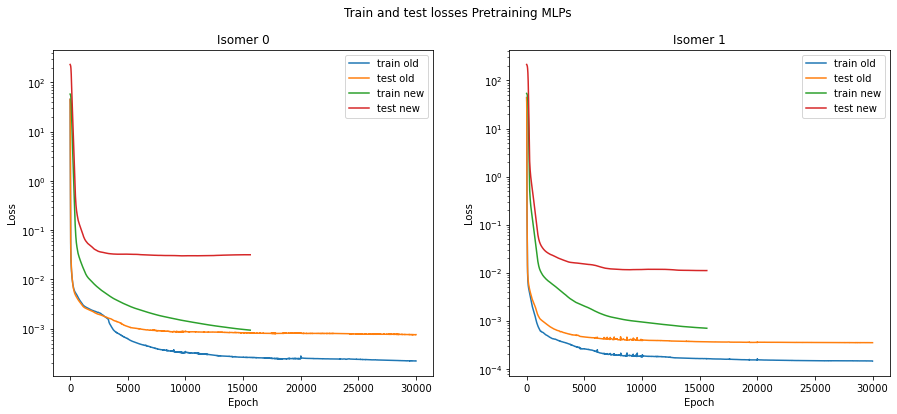

In [49]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

for sim in adaptives_old_new.keys():
    for key in adaptives_old_new[sim].keys():
        train_losses = []
        test_losses = []
        training = adaptives_old_new[sim][key]['dict_mlps'][0]
        if sim == 'old':
            train_losses.append(training[0]['train_losses'])
            test_losses.append(training[0]['test_losses'])
        if sim == 'new':
            train_losses.append(training[0]['avg_train_losses'])
            test_losses.append(training[0]['avg_test_losses'])
        train_losses_flat = [loss for sublist in train_losses for loss in sublist]
        test_losses_flat = [loss for sublist in test_losses for loss in sublist]
        
        axs[key].plot(train_losses_flat, label='train {:s}'.format(sim))
        axs[key].plot(test_losses_flat, label='test {:s}'.format(sim))

        axs[key].set_title('Isomer {:d}'.format(key))
        axs[key].set_xlabel('Epoch')
        axs[key].set_ylabel('Loss')
        axs[key].legend()

        axs[key].set_yscale('log')

fig.suptitle('Train and test losses Pretraining MLPs')

Text(0.5, 0.98, 'Train and test losses Adaptive training MLPs')

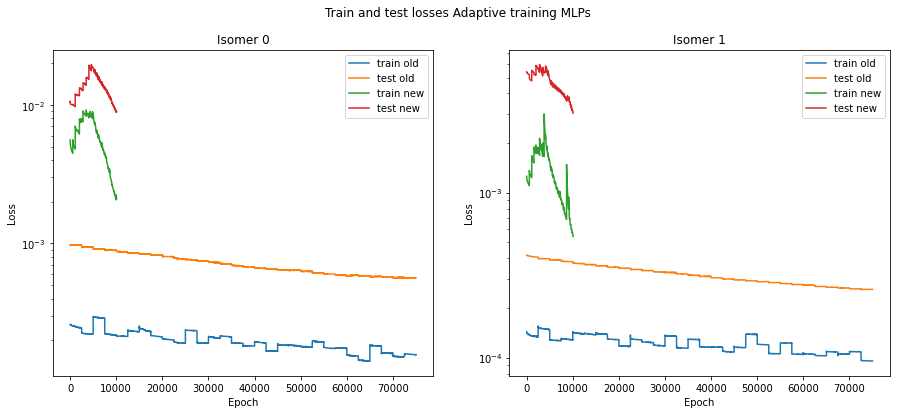

In [50]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

for sim in adaptives_old_new.keys():
    for key in adaptives_old_new[sim].keys():
        train_losses = []
        test_losses = []
        for training in adaptives_old_new[sim][key]['dict_mlps'][1:]:
            if sim == 'old':
                train_losses.append(training[0]['train_losses'])
                test_losses.append(training[0]['test_losses'])
            if sim == 'new':
                train_losses.append(training[0]['avg_train_losses'])
                test_losses.append(training[0]['avg_test_losses'])
        train_losses_flat = [loss for sublist in train_losses for loss in sublist]
        test_losses_flat = [loss for sublist in test_losses for loss in sublist]
        
        axs[key].plot(train_losses_flat, label='train {:s}'.format(sim))
        axs[key].plot(test_losses_flat, label='test {:s}'.format(sim))

        axs[key].set_title('Isomer {:d}'.format(key))
        axs[key].set_xlabel('Epoch')
        axs[key].set_ylabel('Loss')
        axs[key].legend()

        axs[key].set_yscale('log')

fig.suptitle('Train and test losses Adaptive training MLPs')

In [51]:
rhat_df = []
method = 'adaptive'
for simulation in simulation_types[method]:
    for isomer_label in [0, 1]:

        us = torch.cat(adaptives[simulation][isomer_label]['us']).reshape(1000, 50, 1)
        cvs = cvss[simulation][isomer_label]
        
        time_slices = adaptives[simulation][isomer_label]['time_mcmc']
        time_flatten = [t for time_slice in time_slices for t in time_slice]
        time_min = min(time_flatten)
        time_mcmc = np.array([t - time_min for t in time_flatten])/3600

        rhat_info = torch.cat((cvs, us), dim=2).detach().numpy()[500:].transpose(1, 0, 2)

        rhat = R_hat(rhat_info, labels=['C', 'R', 'U'])
        time_ = time_mcmc[rhat[1]]
        time_min = min(time_)
        time_mcmc = np.array([t - time_min for t in time_])

        df = pd.DataFrame(rhat[0], columns=['C', 'R', 'U'])
        df['Time (h)'] = time_mcmc
        df['MCMC step'] = rhat[1]
        df['Method'] = simulation
        df['Isomer'] = isomer_label

        rhat_df.append(df)

rhat_df = pd.concat(rhat_df)

In [52]:
import seaborn as sns

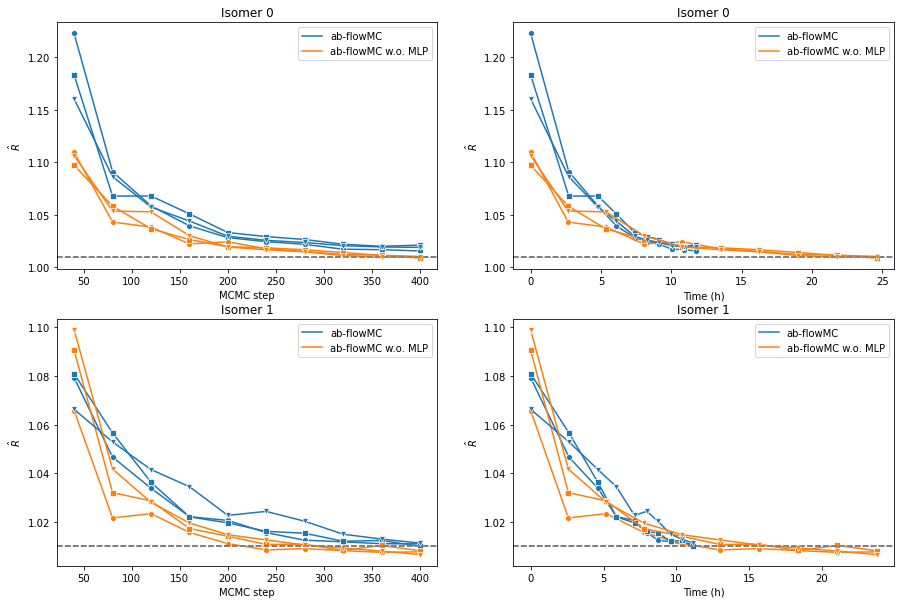

In [53]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
markers = dict(zip(['C', 'R', 'U'], ['o', 's', 'v']))
for isomer in [0, 1]:
    for j, x_axis in enumerate(['MCMC step', 'Time (h)']): 
        for y_axis in ['C', 'R', 'U']:    
            sns.lineplot(data=rhat_df[rhat_df['Isomer'] == isomer], 
                x=x_axis, 
                y=y_axis, 
                hue='Method',
                marker=markers[y_axis], 
                ax=axs[isomer, j],
                )

            axs[isomer, j].axhline(y=1.01, color='gray', linestyle='--')

            axs[isomer, j].set_title('Isomer {:d}'.format(isomer))
            axs[isomer, j].set_xlabel(x_axis)
            axs[isomer, j].set_ylabel(r'$\hat{R}$')


            handles, labels = axs[isomer, j].get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            axs[isomer, j].legend(by_label.values(), by_label.keys())

In [54]:
adaptives_old_new['old'][0]['args'].keys()

dict_keys(['threads', 'process_id', 'random_seed', 'folder_path', 'dataset', 'N', 'isomer_label', 'flow_n_iter', 'flow_learning_rate', 'flow_batch_size', 'n_blocks', 'hidden_dim', 'hidden_depth', 'flow_use_scheduler', 'flow_step_scheduler', 'mlp_n_iter', 'mlp_learning_rate', 'mlp_batch_size', 'mlp_use_scheduler', 'mlp_step_scheduler', 'temperature', 'n_runs', 'n_chains', 'n_steps', 'energy_type', 'frac_computed', 'train_mlps', 'load_models', 'flow_type', 'update_weights', 'scheduler_weights', 'alpha', 'mlps_id', 'flows_id', 'date_start', 'date_end', 'algorithm', 'time_init'])

In [55]:
columns = ['Number of iterations', 'Batch size', 'Learning rate']
rows = ['Previous results', 'New results']

df = pd.DataFrame(columns=columns, index=rows)
df['Number of iterations'] = [
    adaptives_old_new['old'][0]['args']['mlp_n_iter'],
    adaptives_old_new['new'][0]['args']['mlp_n_iter']
]
df['Batch size'] = [
    adaptives_old_new['old'][0]['args']['mlp_batch_size'],
    adaptives_old_new['new'][0]['args']['mlp_batch_size']
]

df['Learning rate'] = [
    adaptives_old_new['old'][0]['args']['mlp_learning_rate'],
    adaptives_old_new['new'][0]['args']['mlp_learning_rate']
]

In [56]:
df

,Number of iterations,Batch size,Learning rate
Previous results,2500,500,0.00001
New results,2500,500,0.00001
